# M5 Data Catalog and Quality Assessment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmavigo/retail-demand-forecasting/blob/main/notebooks/00_DATA_CATALOG_AND_QUALITY.ipynb)

**Purpose:** inspect every official competition file before modeling. This notebook explains what each table contains, profiles missing values and duplicates, validates table relationships, measures price coverage and identifies data-quality risks.

> **Public portfolio snapshot:** the outputs below were generated from the official Kaggle M5 competition files. A private Kaggle token is required only to rerun the download; no credential is stored in this repository.

## 1. Environment

Run the notebook from top to bottom. In Google Colab, this cell installs the small set of required packages.

In [1]:
from pathlib import Path
import sys
import subprocess

if 'google.colab' in sys.modules:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'kagglehub>=1.0,<2', 'pandas>=2.2,<3', 'numpy>=2,<3', 'matplotlib>=3.9,<4',
    ])

import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_seq_items', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'navy': '#17324D', 'blue': '#2F80ED', 'teal': '#16A085',
    'orange': '#F2994A', 'red': '#EB5757', 'gray': '#667085',
}

mkdir -p failed for path C:\Users\ericv\AppData\Local\matplotlib: [WinError 5] Acceso denegado: 'C:\\Users\\ericv\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\ericv\AppData\Local\Temp\matplotlib-72quvyfv because there was an issue with the default path (C:\Users\ericv\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Authenticate and download the official files

1. Accept the [M5 competition rules](https://www.kaggle.com/competitions/m5-forecasting-accuracy/rules).
2. Create an API token in [Kaggle Settings](https://www.kaggle.com/settings/api).
3. In Colab, save it in **Secrets** as `KAGGLE_API_TOKEN` and enable notebook access.

If the secret is unavailable, `kagglehub.login()` opens an interactive login form. Never paste a token into a public code cell.

In [2]:
import kagglehub

# Reuse a local authorized copy when available; otherwise download from Kaggle.
local_data = Path('data/raw')
if (local_data / 'calendar.csv').exists():
    path = local_data
    print('Using the local authorized M5 copy.')
else:
    try:
        path = kagglehub.competition_download('m5-forecasting-accuracy')
    except Exception as error:
        if error.__class__.__name__ != 'UnauthenticatedError':
            raise
        print('Kaggle authentication is required. Paste your private API token in the login form.')
        kagglehub.login()
        path = kagglehub.competition_download('m5-forecasting-accuracy')

DATA_DIR = Path(path)
if not (DATA_DIR / 'calendar.csv').exists():
    DATA_DIR = next(candidate.parent for candidate in DATA_DIR.rglob('calendar.csv'))

required_files = {
    'calendar.csv', 'sell_prices.csv', 'sales_train_validation.csv',
    'sales_train_evaluation.csv', 'sample_submission.csv',
}
available_files = {candidate.name for candidate in DATA_DIR.glob('*.csv')}
assert required_files.issubset(available_files), f'Missing files: {sorted(required_files - available_files)}'
print('Official M5 files available:', len(required_files))


Using the local authorized M5 copy.
Official M5 files available: 5


C:\Users\ericv\Documents\Codex\2026-09-16\new-chat\work\notebook-runtime\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Load every source table

All five official CSV files are loaded. The validation and evaluation sales tables are wide matrices: one row per product-store series and one column per historical day.

In [3]:
file_roles = {
    'calendar': 'Dates, retail weeks, events and SNAP program flags',
    'sell_prices': 'Weekly selling price by store and product',
    'sales_train_validation': 'Daily unit sales through d_1913',
    'sales_train_evaluation': 'Daily unit sales through d_1941',
    'sample_submission': 'Required 28-day forecast submission structure',
}

tables = {
    name: pd.read_csv(DATA_DIR / f'{name}.csv', parse_dates=['date'] if name == 'calendar' else None)
    for name in file_roles
}

calendar = tables['calendar']
prices = tables['sell_prices']
sales_validation = tables['sales_train_validation']
sales_evaluation = tables['sales_train_evaluation']
submission = tables['sample_submission']

catalog = pd.DataFrame([
    {
        'table': name,
        'rows': len(table),
        'columns': table.shape[1],
        'memory_mb': table.memory_usage(deep=True).sum() / 1024**2,
        'role': file_roles[name],
    }
    for name, table in tables.items()
]).sort_values('memory_mb', ascending=False)

display(catalog.style.format({'rows': '{:,.0f}', 'columns': '{:,.0f}', 'memory_mb': '{:,.1f} MB'}))

,table,rows,columns,memory_mb,role
1,sell_prices,"6,841,121",4,853.1 MB,Weekly selling price by store and product
3,sales_train_evaluation,"30,490","1,947",461.9 MB,Daily unit sales through d_1941
2,sales_train_validation,"30,490","1,919",455.4 MB,Daily unit sales through d_1913
4,sample_submission,"60,980",29,17.5 MB,Required 28-day forecast submission structure
0,calendar,"1,969",14,0.6 MB,"Dates, retail weeks, events and SNAP program flags"


## 4. Step 1 — Discover what each table actually contains

We do **not** apply the same statistics to every file. First, we inspect structure and meaning. Then we classify the columns and choose the analysis that fits them.

| Table | What we find first | Suitable next analysis |
|---|---|---|
| `calendar` | Dates, events, categorical labels and binary program flags | Temporal and categorical description |
| `sell_prices` | Identifiers plus one continuous numeric measure | Numeric price description and categorical coverage |
| `sales_train_*` | Product hierarchy plus thousands of daily unit measures | Demand description, time-series analysis and forecasting |
| `sample_submission` | Identifier plus required forecast columns | Structural validation only |

**Rule:** inferential statistics are used only after defining a population, a sample and a business hypothesis. These competition files mostly describe the complete observed M5 history, so the first appropriate stage is descriptive analysis.


### 4.1 Common structural inspection

These commands answer the same neutral questions for every file: How large is it? What do the first records look like? Which columns exist? What type did pandas assign? How many values are present? No statistical interpretation is made yet.


In [4]:
for table_name, df in tables.items():
    print(f"\n{'=' * 90}\n{table_name}\n{'=' * 90}")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    display(df.head(5))
    print("Columns:")
    display(pd.Series(df.columns, name='column').to_frame())
    print("Data types:")
    display(df.dtypes.astype(str).rename('dtype').to_frame())
    print("DataFrame information:")
    df.info()



calendar
Shape: 1,969 rows × 14 columns


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


Columns:


,column
0,date
1,wm_yr_wk
2,weekday
3,wday
4,month
5,year
6,d
7,event_name_1
8,event_type_1
9,event_name_2


Data types:


...

Columns:


,column
0,id
1,F1
2,F2
3,F3
4,F4
5,F5
6,F6
7,F7
8,F8
9,F9


Data types:


,dtype
id,str
F1,int64
F2,int64
F3,int64
F4,int64
F5,int64
F6,int64
F7,int64
F8,int64
F9,int64


DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 60980 entries, 0 to 60979
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      60980 non-null  str  
 1   F1      60980 non-null  int64
 2   F2      60980 non-null  int64
 3   F3      60980 non-null  int64
 4   F4      60980 non-null  int64
 5   F5      60980 non-null  int64
 6   F6      60980 non-null  int64
 7   F7      60980 non-null  int64
 8   F8      60980 non-null  int64
 9   F9      60980 non-null  int64
 10  F10     60980 non-null  int64
 11  F11     60980 non-null  int64
 12  F12     60980 non-null  int64
 13  F13     60980 non-null  int64
 14  F14     60980 non-null  int64
 15  F15     60980 non-null  int64
 16  F16     60980 non-null  int64
 17  F17     60980 non-null  int64
 18  F18     60980 non-null  int64
 19  F19     60980 non-null  int64
 20  F20     60980 non-null  int64
 21  F21     60980 non-null  int64
 22  F22     60980 non-null  int64
 23 

### 4.2 Classify columns before calculating statistics

A numeric storage type does not automatically mean a variable should receive averages or standard deviations. For example, `wm_yr_wk` is stored as an integer but acts as a time key. This classification determines the analysis.


In [5]:
column_classification = pd.DataFrame([
    ['calendar', 'date', 'temporal', 'Date range, continuity and seasonality'],
    ['calendar', 'wm_yr_wk / weekday / events', 'key or categorical', 'Unique values, frequencies and missing labels'],
    ['calendar', 'snap_CA / snap_TX / snap_WI', 'binary flag', 'Active-day counts and percentages'],
    ['sell_prices', 'store_id / item_id / wm_yr_wk', 'key or categorical', 'Coverage and uniqueness'],
    ['sell_prices', 'sell_price', 'continuous numeric', 'Distribution, quantiles and outliers'],
    ['sales_train_*', 'id / item / department / category / store / state', 'key or categorical', 'Hierarchy and coverage'],
    ['sales_train_*', 'd_1 ... d_1941', 'numeric time series', 'Units, zeros, variability, trends and seasonality'],
    ['sample_submission', 'id / F1 ... F28', 'output schema', 'Column, row and default-value validation'],
], columns=['table', 'columns', 'semantic_type', 'appropriate_analysis'])
display(column_classification)


,table,columns,semantic_type,appropriate_analysis
0,calendar,date,temporal,"Date range, continuity and seasonality"
1,calendar,wm_yr_wk / weekday / events,key or categorical,"Unique values, frequencies and missing labels"
2,calendar,snap_CA / snap_TX / snap_WI,binary flag,Active-day counts and percentages
3,sell_prices,store_id / item_id / wm_yr_wk,key or categorical,Coverage and uniqueness
4,sell_prices,sell_price,continuous numeric,"Distribution, quantiles and outliers"
5,sales_train_*,id / item / department / category / store / state,key or categorical,Hierarchy and coverage
6,sales_train_*,d_1 ... d_1941,numeric time series,"Units, zeros, variability, trends and seasonality"
7,sample_submission,id / F1 ... F28,output schema,"Column, row and default-value validation"


### 4.3 `calendar.csv` — temporal and categorical discovery

`calendar` is not treated as a conventional numeric table. We parse the date, inspect its coverage, count categories and events, and measure the binary SNAP flags. We deliberately avoid calculating a mean for identifier columns such as `wm_yr_wk`.


In [6]:
calendar_view = calendar.copy()
calendar_view['date'] = pd.to_datetime(calendar_view['date'])

calendar_overview = pd.DataFrame({
    'value': [
        f"{calendar_view['date'].min():%Y-%m-%d}",
        f"{calendar_view['date'].max():%Y-%m-%d}",
        f"{calendar_view.shape[0]:,}",
        f"{calendar_view['wm_yr_wk'].nunique():,}",
        f"{calendar_view['event_name_1'].notna().sum():,}",
        f"{calendar_view['event_name_2'].notna().sum():,}",
    ]
}, index=['first_date', 'last_date', 'calendar_days', 'retail_weeks',
          'days_with_primary_event', 'days_with_secondary_event'])
display(calendar_overview)

calendar_categories = {
    column: calendar_view[column].value_counts(dropna=False).rename_axis(column).to_frame('days')
    for column in ['weekday', 'event_type_1', 'event_type_2']
}
for label, result in calendar_categories.items():
    print(f"Frequency table: {label}")
    display(result)

snap_summary = calendar_view[['snap_CA', 'snap_TX', 'snap_WI']].agg(['sum', 'mean']).T
snap_summary.columns = ['active_days', 'active_share']
display(snap_summary.style.format({'active_days': '{:,.0f}', 'active_share': '{:.1%}'}))


,value
first_date,2011-01-29
last_date,2016-06-19
calendar_days,"1,969"
retail_weeks,282
days_with_primary_event,162
days_with_secondary_event,5


Frequency table: weekday


,days
weekday,
Saturday,282
Sunday,282
Monday,281
Tuesday,281
Wednesday,281
Thursday,281
Friday,281


Frequency table: event_type_1


,days
event_type_1,
NaN,1807
Religious,55
National,52
Cultural,37
Sporting,18


Frequency table: event_type_2


,days
event_type_2,
NaN,1964
Cultural,4
Religious,1


,active_days,active_share
snap_CA,650,33.0%
snap_TX,650,33.0%
snap_WI,650,33.0%


**Decision after discovery:** use descriptive temporal and categorical analysis. Later, event and SNAP fields can become explanatory variables in forecasting. Inferential tests would require a specific hypothesis, such as whether comparable event days change demand after controlling for store, product and season.


### 4.4 `sell_prices.csv` — mixed categorical and numeric discovery

Only `sell_price` is a continuous measure. Store, item and retail-week fields identify where and when that price applies.


In [7]:
price_structure = pd.DataFrame({
    'value': [
        f"{prices.shape[0]:,}",
        f"{prices['store_id'].nunique():,}",
        f"{prices['item_id'].nunique():,}",
        f"{prices['wm_yr_wk'].nunique():,}",
        f"{prices['sell_price'].isna().sum():,}",
    ]
}, index=['rows', 'stores', 'products', 'retail_weeks', 'missing_prices'])
display(price_structure)

display(prices[['sell_price']].describe(percentiles=[.01, .25, .50, .75, .99]).T.style.format('{:,.2f}'))
display(prices.groupby('store_id', as_index=False)['sell_price']
        .agg(records='size', products='nunique', average_price='mean', median_price='median')
        .sort_values('records', ascending=False)
        .style.format({'records': '{:,.0f}', 'products': '{:,.0f}',
                       'average_price': '${:,.2f}', 'median_price': '${:,.2f}'}))


,value
rows,"6,841,121"
stores,10
products,"3,049"
retail_weeks,282
missing_prices,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
sell_price,"6,841,121.00",4.41,3.41,0.01,0.48,2.18,3.47,5.84,17.92,107.32


,store_id,records,products,average_price,median_price
5,TX_2,"701,214",731,$4.37,$3.42
4,TX_1,"699,796",749,$4.37,$3.42
0,CA_1,"698,412",661,$4.41,$3.47
9,WI_3,"696,094",704,$4.42,$3.47
2,CA_3,"693,990",699,$4.39,$3.44
6,TX_3,"691,112",727,$4.39,$3.44
3,CA_4,"679,025",647,$4.42,$3.47
8,WI_2,"678,171",730,$4.44,$3.47
7,WI_1,"665,912",702,$4.46,$3.48
1,CA_2,"637,395",643,$4.45,$3.48


**Decision after discovery:** descriptive numeric analysis is appropriate for `sell_price`; coverage and frequency analysis are appropriate for its identifiers. Inferential analysis is postponed until a testable pricing question is defined.


### 4.5 Sales tables — hierarchy plus numeric time series

These files mix categorical identifiers with daily unit measurements. We inspect those two parts separately instead of passing the entire wide table to one generic `describe()` call.


In [8]:
sales_id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
validation_day_columns = [c for c in sales_validation.columns if c.startswith('d_')]
evaluation_day_columns = [c for c in sales_evaluation.columns if c.startswith('d_')]

sales_structure = pd.DataFrame([
    ['sales_train_validation', len(sales_validation), len(validation_day_columns),
     sales_validation.item_id.nunique(), sales_validation.store_id.nunique()],
    ['sales_train_evaluation', len(sales_evaluation), len(evaluation_day_columns),
     sales_evaluation.item_id.nunique(), sales_evaluation.store_id.nunique()],
], columns=['table', 'series', 'daily_columns', 'products', 'stores'])
display(sales_structure.style.format({c: '{:,.0f}' for c in ['series', 'daily_columns', 'products', 'stores']}))

print('Identifier and hierarchy coverage')
display(pd.DataFrame({
    column: [sales_evaluation[column].nunique(), sales_evaluation[column].isna().sum()]
    for column in sales_id_columns
}, index=['unique_values', 'missing_values']).T)

sales_values = sales_evaluation[evaluation_day_columns].to_numpy()
sales_numeric_summary = pd.DataFrame({
    'value': [sales_values.size, sales_values.sum(), (sales_values == 0).sum(),
              sales_values.min(), sales_values.max()]
}, index=['observations', 'units_sold', 'zero_unit_observations',
          'minimum_daily_units', 'maximum_daily_units'])
display(sales_numeric_summary.style.format({'value': '{:,.0f}'}))


,table,series,daily_columns,products,stores
0,sales_train_validation,"30,490","1,913","3,049",10
1,sales_train_evaluation,"30,490","1,941","3,049",10


Identifier and hierarchy coverage


,unique_values,missing_values
id,30490,0
item_id,3049,0
dept_id,7,0
cat_id,3,0
store_id,10,0
state_id,3,0


,value
observations,"59,181,090"
units_sold,"66,927,173"
zero_unit_observations,"40,241,819"
minimum_daily_units,0
maximum_daily_units,763


**Decision after discovery:** descriptive time-series analysis is appropriate, followed by forecasting. Possible inferential work must begin with a defined comparison, such as estimating an event effect with uncertainty rather than merely comparing two uncontrolled averages.


### 4.6 `sample_submission.csv` — schema validation, not business analysis

This file tells us the format Kaggle expects. Its `F1`–`F28` values are placeholders, so their means and standard deviations do not describe retail demand.


In [9]:
forecast_columns = [c for c in submission.columns if c.startswith('F')]
submission_check = pd.DataFrame({
    'value': [
        f"{submission.shape[0]:,}",
        f"{len(forecast_columns):,}",
        str(forecast_columns[0]),
        str(forecast_columns[-1]),
        f"{submission['id'].duplicated().sum():,}",
        f"{submission[forecast_columns].isna().sum().sum():,}",
        f"{(submission[forecast_columns] == 0).sum().sum():,}",
    ]
}, index=['rows', 'forecast_columns', 'first_forecast_column', 'last_forecast_column',
          'duplicate_ids', 'missing_forecast_cells', 'zero_placeholder_cells'])
display(submission_check)


,value
rows,"60,980"
forecast_columns,28
first_forecast_column,F1
last_forecast_column,F28
duplicate_ids,0
missing_forecast_cells,0
zero_placeholder_cells,"1,707,440"


**Decision after discovery:** validate shape, identifiers and forecast columns only. Statistical analysis begins after the placeholders are replaced with model predictions.


### 4.7 Analysis decision gate

Before continuing, each proposed analysis must answer these questions:

1. **What does the column mean?** A measure, category, date, key, flag or output placeholder?
2. **What question are we answering?** Description, comparison, relationship or prediction?
3. **Do we observe the full available history or a sample from a larger population?**
4. **If inference is proposed, what is the population, hypothesis, uncertainty measure and source of dependence?**

For this project, the next valid step is primarily **descriptive analysis and data-quality validation**. Inferential analysis will be added only where it supports a precise business question and respects the time-series structure.


## 5. Understand the complete data model

The table below groups thousands of repeated daily columns into understandable business fields. The exact number and range of daily columns are calculated directly from the files.

In [10]:
validation_days = [column for column in sales_validation.columns if column.startswith('d_')]
evaluation_days = [column for column in sales_evaluation.columns if column.startswith('d_')]
forecast_columns = [column for column in submission.columns if column.startswith('F')]

data_dictionary = pd.DataFrame([
    ['calendar', 'date / d / wm_yr_wk', 'Date key, sequential day key and retail-week key'],
    ['calendar', 'weekday / wday / month / year', 'Calendar attributes'],
    ['calendar', 'event_name_1/2 and event_type_1/2', 'Optional event descriptions; blank means no event'],
    ['calendar', 'snap_CA / snap_TX / snap_WI', 'State-level SNAP eligibility flags'],
    ['sell_prices', 'store_id / item_id / wm_yr_wk', 'Composite key identifying a weekly product price'],
    ['sell_prices', 'sell_price', 'Weekly product selling price'],
    ['sales_train_*', 'id / item_id / dept_id / cat_id / store_id / state_id', 'Series and hierarchy identifiers'],
    ['sales_train_validation', f'{validation_days[0]} … {validation_days[-1]}', f'{len(validation_days):,} daily unit-sales columns'],
    ['sales_train_evaluation', f'{evaluation_days[0]} … {evaluation_days[-1]}', f'{len(evaluation_days):,} daily unit-sales columns'],
    ['sample_submission', 'id', 'Series identifier for validation and evaluation forecasts'],
    ['sample_submission', f'{forecast_columns[0]} … {forecast_columns[-1]}', f'{len(forecast_columns):,} forecast-horizon columns'],
], columns=['table', 'field_or_group', 'meaning'])

display(data_dictionary)
print(f'Calendar coverage: {calendar.date.min():%Y-%m-%d} to {calendar.date.max():%Y-%m-%d}')
print(f'Validation history: {len(validation_days):,} days | Evaluation history: {len(evaluation_days):,} days')
print(f'Forecast horizon: {len(forecast_columns):,} days')

,table,field_or_group,meaning
0,calendar,date / d / wm_yr_wk,"Date key, sequential day key and retail-week key"
1,calendar,weekday / wday / month / year,Calendar attributes
2,calendar,event_name_1/2 and event_type_1/2,Optional event descriptions; blank means no event
3,calendar,snap_CA / snap_TX / snap_WI,State-level SNAP eligibility flags
4,sell_prices,store_id / item_id / wm_yr_wk,Composite key identifying a weekly product price
5,sell_prices,sell_price,Weekly product selling price
6,sales_train_*,id / item_id / dept_id / cat_id / store_id / s...,Series and hierarchy identifiers
7,sales_train_validation,d_1 … d_1913,"1,913 daily unit-sales columns"
8,sales_train_evaluation,d_1 … d_1941,"1,941 daily unit-sales columns"
9,sample_submission,id,Series identifier for validation and evaluatio...


Calendar coverage: 2011-01-29 to 2016-06-19
Validation history: 1,913 days | Evaluation history: 1,941 days
Forecast horizon: 28 days


## 6. Missing-value audit

Missing event names are expected: most dates do not contain a special event. Missing values in identifiers, prices or sales measurements would be a material quality problem.

In [11]:
quality_rows = []
missing_details = []

for name, table in tables.items():
    missing = table.isna().sum()
    missing_cells = int(missing.sum())
    quality_rows.append({
        'table': name,
        'rows': len(table),
        'columns': table.shape[1],
        'missing_cells': missing_cells,
        'missing_percent': missing_cells / table.size,
        'columns_with_missing': int(missing.gt(0).sum()),
    })
    for column, count in missing[missing.gt(0)].items():
        missing_details.append({
            'table': name,
            'column': column,
            'missing_rows': int(count),
            'missing_percent': count / len(table),
        })

quality_summary = pd.DataFrame(quality_rows).sort_values('missing_percent', ascending=False)
missing_columns = pd.DataFrame(missing_details).sort_values(['table', 'missing_percent'], ascending=[True, False])

display(quality_summary.style.format({
    'rows': '{:,.0f}', 'columns': '{:,.0f}', 'missing_cells': '{:,.0f}',
    'missing_percent': '{:.2%}', 'columns_with_missing': '{:,.0f}',
}))
display(missing_columns.style.format({'missing_rows': '{:,.0f}', 'missing_percent': '{:.2%}'}))

,table,rows,columns,missing_cells,missing_percent,columns_with_missing
0,calendar,"1,969",14,"7,542",27.36%,4
1,sell_prices,"6,841,121",4,0,0.00%,0
2,sales_train_validation,"30,490","1,919",0,0.00%,0
3,sales_train_evaluation,"30,490","1,947",0,0.00%,0
4,sample_submission,"60,980",29,0,0.00%,0


,table,column,missing_rows,missing_percent
2,calendar,event_name_2,"1,964",99.75%
3,calendar,event_type_2,"1,964",99.75%
0,calendar,event_name_1,"1,807",91.77%
1,calendar,event_type_1,"1,807",91.77%


## 7. Keys, duplicates and cross-table consistency

These checks test whether each business key is unique and whether the five files agree structurally.

In [12]:
id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

prefix_matches = True
for start in range(0, len(sales_evaluation), 1_000):
    stop = min(start + 1_000, len(sales_evaluation))
    evaluation_block = sales_evaluation.iloc[start:stop][validation_days].to_numpy(dtype=np.int32)
    validation_block = sales_validation.iloc[start:stop][validation_days].to_numpy(dtype=np.int32)
    if not np.array_equal(evaluation_block, validation_block):
        prefix_matches = False
        break

checks = pd.DataFrame([
    ['calendar day key is unique', not calendar.d.duplicated().any(), 'calendar.d'],
    ['calendar date is unique', not calendar.date.duplicated().any(), 'calendar.date'],
    ['weekly price key is unique', not prices.duplicated(['store_id', 'item_id', 'wm_yr_wk']).any(), 'store + item + week'],
    ['validation series ID is unique', not sales_validation.id.duplicated().any(), 'validation.id'],
    ['evaluation series ID is unique', not sales_evaluation.id.duplicated().any(), 'evaluation.id'],
    ['submission series ID is unique', not submission.id.duplicated().any(), 'submission.id'],
    ['validation and evaluation row order matches', sales_validation[id_columns[1:]].equals(sales_evaluation[id_columns[1:]]), 'hierarchy columns'],
    ['evaluation contains the complete validation history', prefix_matches, f'{validation_days[0]} … {validation_days[-1]}'],
    ['evaluation adds exactly 28 observed days', len(evaluation_days) - len(validation_days) == 28, f'{evaluation_days[-28]} … {evaluation_days[-1]}'],
    ['submission contains validation and evaluation rows', len(submission) == 2 * len(sales_evaluation), '60,980 expected rows'],
], columns=['check', 'passed', 'scope'])

checks['status'] = np.where(checks.passed, 'PASS', 'REVIEW')
display(checks[['status', 'check', 'scope']])
assert checks.passed.all(), 'At least one structural integrity check failed.'

,status,check,scope
0,PASS,calendar day key is unique,calendar.d
1,PASS,calendar date is unique,calendar.date
2,PASS,weekly price key is unique,store + item + week
3,PASS,validation series ID is unique,validation.id
4,PASS,evaluation series ID is unique,evaluation.id
5,PASS,submission series ID is unique,submission.id
6,PASS,validation and evaluation row order matches,hierarchy columns
7,PASS,evaluation contains the complete validation hi...,d_1 … d_1913
8,PASS,evaluation adds exactly 28 observed days,d_1914 … d_1941
9,PASS,submission contains validation and evaluation ...,"60,980 expected rows"


## 8. Calendar, hierarchy and domain coverage

This section lists the business dimensions available for analysis and modeling.

In [13]:
domain_summary = pd.DataFrame([
    ['states', sales_evaluation.state_id.nunique(), ', '.join(sorted(sales_evaluation.state_id.unique()))],
    ['stores', sales_evaluation.store_id.nunique(), ', '.join(sorted(sales_evaluation.store_id.unique()))],
    ['categories', sales_evaluation.cat_id.nunique(), ', '.join(sorted(sales_evaluation.cat_id.unique()))],
    ['departments', sales_evaluation.dept_id.nunique(), ', '.join(sorted(sales_evaluation.dept_id.unique()))],
    ['products', sales_evaluation.item_id.nunique(), 'Product identifiers from item_id'],
    ['product-store series', sales_evaluation.id.nunique(), 'One row per item and store'],
    ['event names', calendar.event_name_1.nunique(dropna=True), 'Primary named events'],
    ['event types', calendar.event_type_1.nunique(dropna=True), ', '.join(sorted(calendar.event_type_1.dropna().unique()))],
], columns=['dimension', 'count', 'available_values'])

display(domain_summary.style.format({'count': '{:,.0f}'}))

calendar_flags = pd.DataFrame({
    'flag': ['snap_CA', 'snap_TX', 'snap_WI', 'primary_event_days', 'secondary_event_days'],
    'days': [calendar.snap_CA.sum(), calendar.snap_TX.sum(), calendar.snap_WI.sum(), calendar.event_name_1.notna().sum(), calendar.event_name_2.notna().sum()],
})
display(calendar_flags.style.format({'days': '{:,.0f}'}))

,dimension,count,available_values
0,states,3,"CA, TX, WI"
1,stores,10,"CA_1, CA_2, CA_3, CA_4, TX_1, TX_2, TX_3, WI_1, WI_2, WI_3"
2,categories,3,"FOODS, HOBBIES, HOUSEHOLD"
3,departments,7,"FOODS_1, FOODS_2, FOODS_3, HOBBIES_1, HOBBIES_2, HOUSEHOLD_1, HOUSEHOLD_2"
4,products,"3,049",Product identifiers from item_id
5,product-store series,"30,490",One row per item and store
6,event names,30,Primary named events
7,event types,4,"Cultural, National, Religious, Sporting"


,flag,days
0,snap_CA,650
1,snap_TX,650
2,snap_WI,650
3,primary_event_days,162
4,secondary_event_days,5


## 9. Sales-value profile

The sales matrix is processed in blocks to control memory. Zero sales are valid observations and are common in retail demand; negative units would be invalid.

,value
Total units,"66,927,173"
Zero-demand cells,"40,241,819"
Zero-demand share,68.00%
Negative cells,0
Maximum units in one product-store-day,763


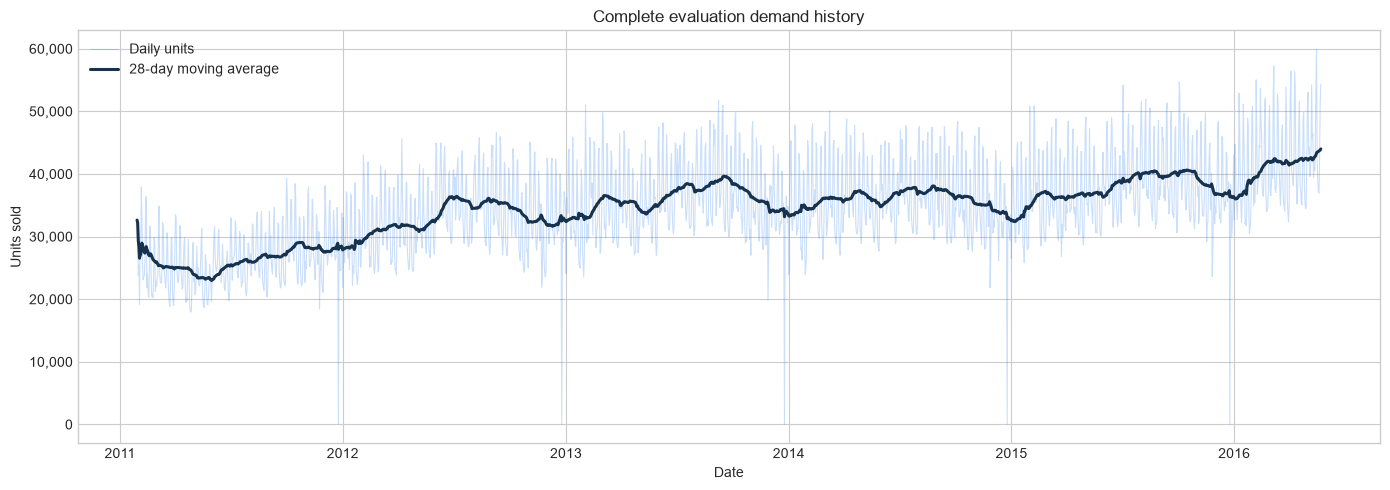

In [14]:
total_units = 0
zero_cells = 0
negative_cells = 0
maximum_daily_units = 0
daily_units = np.zeros(len(evaluation_days), dtype=np.int64)
total_cells = len(sales_evaluation) * len(evaluation_days)

for start in range(0, len(sales_evaluation), 1_000):
    stop = min(start + 1_000, len(sales_evaluation))
    block = sales_evaluation.iloc[start:stop][evaluation_days].to_numpy(dtype=np.int32)
    total_units += int(block.sum())
    zero_cells += int((block == 0).sum())
    negative_cells += int((block < 0).sum())
    maximum_daily_units = max(maximum_daily_units, int(block.max()))
    daily_units += block.sum(axis=0)

sales_profile = pd.DataFrame({
    'value': [
        f'{total_units:,}', f'{zero_cells:,}', f'{zero_cells / total_cells:.2%}',
        f'{negative_cells:,}', f'{maximum_daily_units:,}',
    ]
}, index=['Total units', 'Zero-demand cells', 'Zero-demand share', 'Negative cells', 'Maximum units in one product-store-day'])
display(sales_profile)

daily_sales = calendar.set_index('d').loc[evaluation_days, ['date']].reset_index(drop=True)
daily_sales['units'] = daily_units
daily_sales['moving_average_28'] = daily_sales.units.rolling(28, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales.date, daily_sales.units, color=COLORS['blue'], alpha=0.25, linewidth=0.8, label='Daily units')
ax.plot(daily_sales.date, daily_sales.moving_average_28, color=COLORS['navy'], linewidth=2.2, label='28-day moving average')
ax.set(title='Complete evaluation demand history', xlabel='Date', ylabel='Units sold')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 10. Price profile and sales-price coverage

The price table contains only active product-store weeks. A missing joined price is acceptable when units are zero. A positive sale without a price would understate estimated revenue and must be treated as a quality failure.

,sell_price
count,"$6,841,121.00"
mean,$4.41
std,$3.41
min,$0.01
1%,$0.48
25%,$2.18
50%,$3.47
75%,$5.84
99%,$17.92
max,$107.32


,value
Weekly price records,"6,841,121"
Missing prices inside sell_prices.csv,0
Positive-sales observations,"18,939,271"
Positive sales without joined price,0


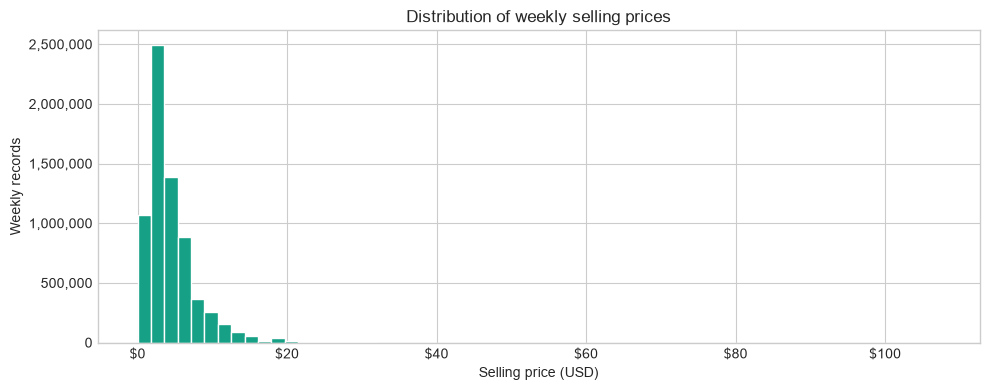

In [15]:
price_profile = prices.sell_price.describe(percentiles=[.01, .25, .50, .75, .99]).to_frame('sell_price')
display(price_profile.style.format({'sell_price': '${:,.2f}'}))

row_index = pd.MultiIndex.from_frame(sales_evaluation[['store_id', 'item_id']])
calendar_days = calendar.set_index('d').loc[evaluation_days].reset_index()
weeks = calendar_days.wm_yr_wk.drop_duplicates().tolist()
price_wide = prices.pivot(index=['store_id', 'item_id'], columns='wm_yr_wk', values='sell_price').reindex(index=row_index, columns=weeks)
week_position = {week: position for position, week in enumerate(weeks)}
day_week_positions = np.array([week_position[week] for week in calendar_days.wm_yr_wk])

positive_sales_without_price = 0
positive_sales_cells = 0
for start in range(0, len(sales_evaluation), 1_000):
    stop = min(start + 1_000, len(sales_evaluation))
    block_units = sales_evaluation.iloc[start:stop][evaluation_days].to_numpy(dtype=np.int32)
    block_prices = price_wide.iloc[start:stop].to_numpy(dtype=np.float32)[:, day_week_positions]
    positive = block_units > 0
    positive_sales_cells += int(positive.sum())
    positive_sales_without_price += int((positive & np.isnan(block_prices)).sum())

coverage = pd.DataFrame({
    'value': [f'{len(prices):,}', f'{prices.sell_price.isna().sum():,}', f'{positive_sales_cells:,}', f'{positive_sales_without_price:,}']
}, index=['Weekly price records', 'Missing prices inside sell_prices.csv', 'Positive-sales observations', 'Positive sales without joined price'])
display(coverage)
assert positive_sales_without_price == 0, 'Revenue cannot be calculated safely: positive sales without price were found.'

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(prices.sell_price, bins=60, color=COLORS['teal'], edgecolor='white')
ax.set(title='Distribution of weekly selling prices', xlabel='Selling price (USD)', ylabel='Weekly records')
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
fig.tight_layout()
plt.show()

## 11. Missingness visualization

Only columns with at least one missing value are shown. These are calendar event descriptors, where blank means that the date has no corresponding event.

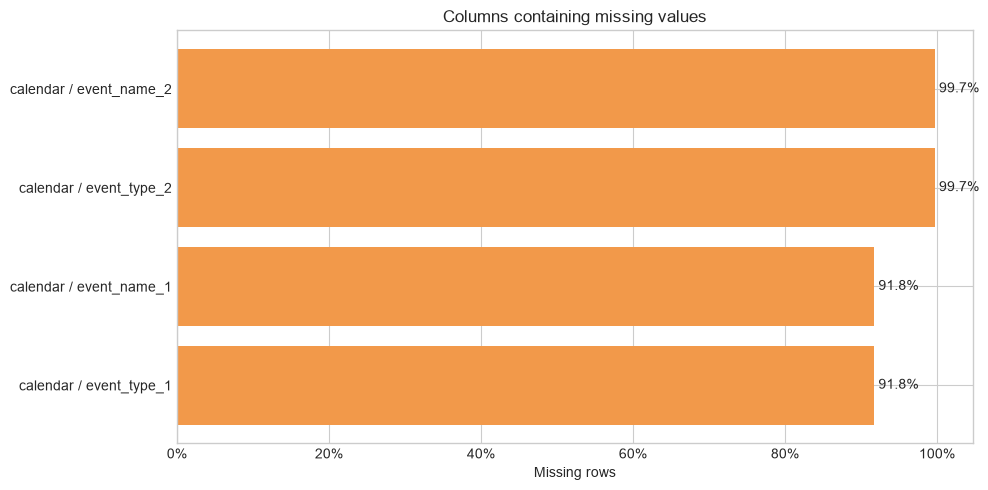

In [16]:
plot_missing = missing_columns.sort_values('missing_percent').copy()
labels = plot_missing.table + ' / ' + plot_missing.column

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels, 100 * plot_missing.missing_percent, color=COLORS['orange'])
ax.set(title='Columns containing missing values', xlabel='Missing rows', ylabel='')
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}%'))
for bar, value in zip(bars, plot_missing.missing_percent):
    ax.text(100 * value, bar.get_y() + bar.get_height()/2, f' {value:.1%}', va='center')
fig.tight_layout()
plt.show()

## 12. Final quality decision

The checks distinguish expected blanks from defects that could invalidate a forecast or revenue calculation.

In [17]:
decision = pd.DataFrame([
    ['File completeness', 'PASS', 'All five official files are available.'],
    ['Primary and composite keys', 'PASS', 'No duplicate business keys were found.'],
    ['Sales measurements', 'PASS', 'No missing or negative unit-sales observations were found.'],
    ['Price measurements', 'PASS', 'sell_prices.csv contains no missing prices.'],
    ['Sales-price relationship', 'PASS', 'Every positive sale has a matching weekly price.'],
    ['Calendar missing values', 'EXPECTED', 'Blank event fields mean that no event occurred.'],
    ['Validation/evaluation relationship', 'PASS', 'Evaluation extends validation by exactly 28 observed days.'],
], columns=['area', 'status', 'interpretation'])
display(decision)

,area,status,interpretation
0,File completeness,PASS,All five official files are available.
1,Primary and composite keys,PASS,No duplicate business keys were found.
2,Sales measurements,PASS,No missing or negative unit-sales observations...
3,Price measurements,PASS,sell_prices.csv contains no missing prices.
4,Sales-price relationship,PASS,Every positive sale has a matching weekly price.
5,Calendar missing values,EXPECTED,Blank event fields mean that no event occurred.
6,Validation/evaluation relationship,PASS,Evaluation extends validation by exactly 28 ob...


## Executive conclusion

The M5 source is suitable for demand forecasting. The sales matrices contain no missing or negative measurements, table keys are unique, evaluation extends validation correctly, and every positive sale can be connected to a weekly price. Missing calendar event fields are meaningful blanks rather than data defects. High zero-demand frequency is a real intermittent-demand characteristic and must be considered when selecting metrics and models.